In [1]:
import torch
import fastjet as fj
import numpy as np
import yaml
import matplotlib.pyplot as plt

from src.data.data_loading import L1TriggerDataModule
from src.models.mlp_vqvae import MLPVQVAE

# -------------------------
# FastJet definition
# -------------------------

jet_def = fj.JetDefinition(
    fj.antikt_algorithm,
    0.4   # jet radius R
)

#Open config file
with open("configs/data/default.yaml") as f:
    config = yaml.safe_load(f)

#Extract config info
dirs_train = config["train_path"]
dirs_val = config["val_path"]
dirs_test = config["test_path"]

max_part = config["max_particles"]

feat = config["features"]


In [2]:

dm_not_prep = L1TriggerDataModule(
    parquet_dirs_train=dirs_train,
    parquet_dirs_val=dirs_val,
    parquet_dirs_test=dirs_test,
    max_particles=max_part,
    batch_size=32,
    features=feat,
    preprocessing=False,
    #num_workers=0,
)

loader_not_prep = dm_not_prep.test_dataloader()

dm_prep = L1TriggerDataModule(
    parquet_dirs_train=dirs_train,
    parquet_dirs_val=dirs_val,
    parquet_dirs_test=dirs_test,
    max_particles=max_part,
    batch_size=32,
    features=feat,
    preprocessing=True,
    #num_workers=0,
)

loader_prep = dm_prep.test_dataloader()


In [3]:
def cluster_jets(valid_particles, R=0.4, pt_min=5.0):
    
    pseudojets = []

    for pt, eta, phi in valid_particles:

        px = pt * torch.cos(phi)
        py = pt * torch.sin(phi)
        pz = pt * torch.sinh(eta)
        E  = pt * torch.cosh(eta)

        pseudojets.append(fj.PseudoJet(px.item(), py.item(), pz.item(), E.item()))

    jet_def = fj.JetDefinition(fj.antikt_algorithm, R)

    # Clustering
    cluster_seq = fj.ClusterSequence(pseudojets, jet_def)

    # Select jets with p_T > p_T_min
    inclusive = cluster_seq.inclusive_jets(pt_min)

    # Extract jets info
    jets_info = [(jet.perp(), jet.eta(), jet.phi(), jet.m()) for jet in inclusive]

    return jets_info

In [4]:
jets = []

for batch in loader_not_prep:

    features, mask = batch
    
    batch_size = features.shape[0]

    for i in range(batch_size):

        event_feats = features[i]
        event_mask = mask[i]

        # Remove padding
        valid_part = event_feats[event_mask]

        j_info = cluster_jets(valid_part, R=0.4, pt_min=5.0)

        jets.append(j_info)

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


In [5]:
j_pt = []
j_eta = []
j_phi = []
j_mass = []

for event in jets:
    for j in event:
        j_pt.append(j[0])
        j_eta.append(j[1])
        j_phi.append(j[2])
        j_mass.append(j[3])


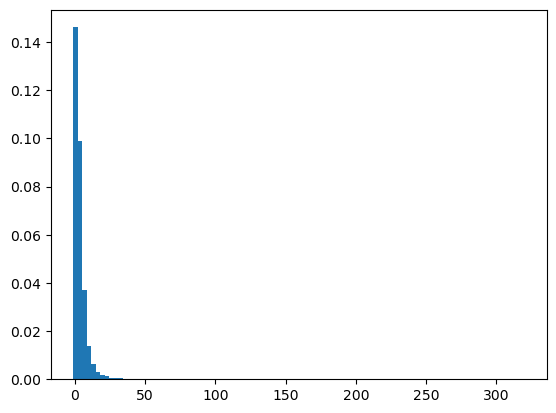

In [6]:
plt.hist(np.array(j_mass), bins=100, density = True)

plt.show()

In [7]:
def PostProcessing(x, m):
     
    x = x.clone()

    # pt
    x[:, :, 0] = torch.where(
        m,
        torch.exp(x[:, :, 0] + 1.8) - 1e-8,
        x[:, :, 0]
    )

    # eta
    x[:, :, 1] = torch.where(
        m,
        x[:, :, 1] * 3,
        x[:, :, 1]
    )

    # phi
    x[:, :, 2] = torch.where(
        m,
        x[:, :, 2] * torch.pi,
        x[:, :, 2]
    )

    return x

In [8]:
ckpt = torch.load(
    "checkpoints/mlp/v0-epoch=01-val_loss=0.0315.ckpt",
    map_location="cpu",
    weights_only=False,   # IMPORTANT
)

model = MLPVQVAE(**ckpt["hyper_parameters"])

model.load_state_dict(ckpt["state_dict"])

model.eval()
model.freeze()

device = "cuda"

model.to(device)

jets_reco = []

with torch.inference_mode():

    for batch in loader_prep:

        features, mask = batch

        features = features.to(device)
        mask = mask.to(device)

        outputs = model(features, mask)

        outputs_post = PostProcessing(outputs[0], mask)

        batch_size = outputs[0].shape[0]

        for i in range(batch_size):

            event_feats = outputs_post[i]
            event_mask = mask[i]

            # Remove padding
            valid_part = event_feats[event_mask]

            j_info = cluster_jets(valid_part, R=0.4, pt_min=5.0)

            jets_reco.append(j_info)  

        

In [9]:
j_pt_reco = []
j_eta_reco = []
j_phi_reco = []
j_mass_reco = []

for event in jets_reco:
    for j in event:
        j_pt_reco.append(j[0])
        j_eta_reco.append(j[1])
        j_phi_reco.append(j[2])
        j_mass_reco.append(j[3])


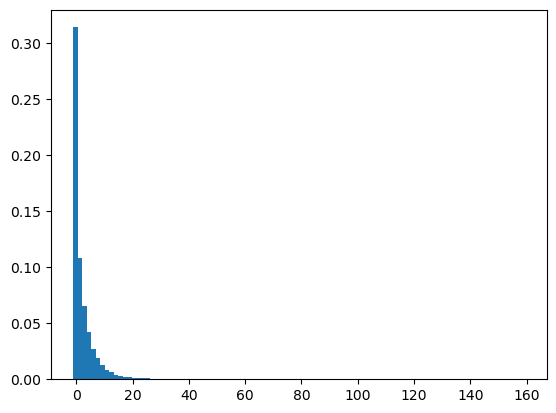

In [10]:
plt.hist(np.array(j_mass_reco), bins=100, density=True)

plt.show()